PHASE 1 (v2): REGENERATING DATASET WITH REALISTIC PASS RATE

Step 1: Generating behavioral features...
10 behavioral features generated
Ability factor generated (hidden confounder, not a feature)

Step 2: Calculating grades (retuned weights)...

Grade stats:
  Mean:   70.4
  Std:    12.5
  Min:    32.9
  Max:    100.0

Pass rate: 80.5%  (805 pass / 195 fail)
Pass rate is in realistic range (70-82%) — good!

Step 4: Building dataset (ability_factor excluded from features)...
Dataset shape: (1000, 12)

Step 5: Visualizing new distributions...
Saved: dataset_v2_distribution.png
Saved: student_performance_data.csv (overwrites v1)


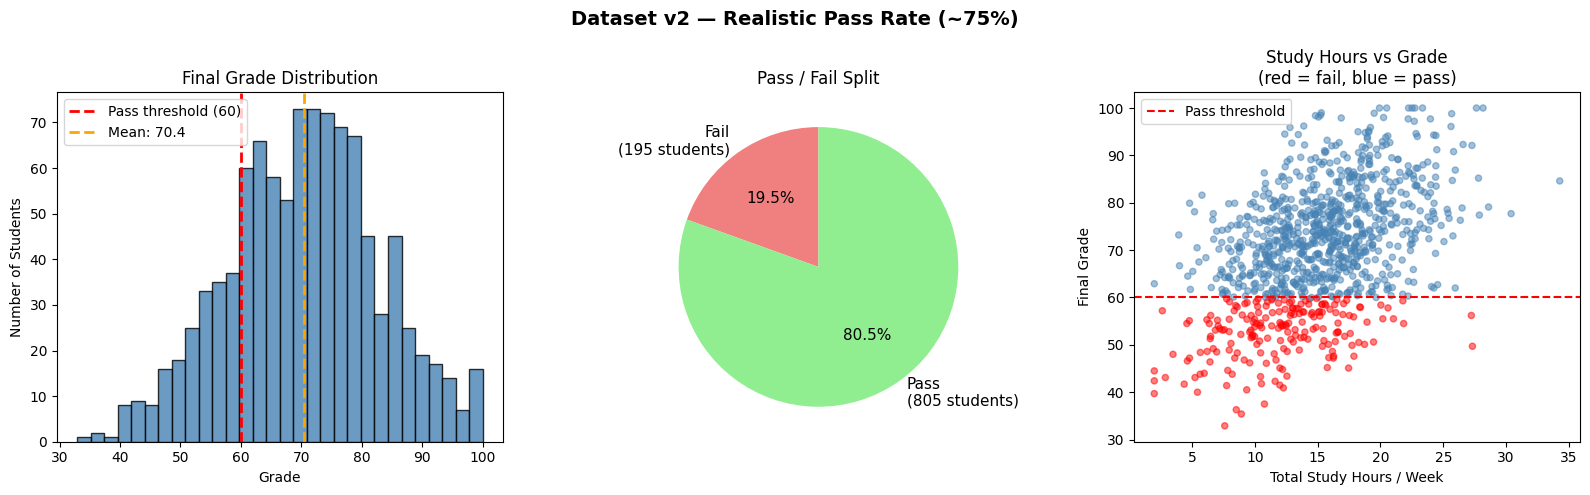

In [ ]:
"""
Phase 1 (v2) + Phase 2: Regenerate Dataset with Realistic Pass Rate

Changes from v1:
- Added 'ability_factor': simulates prior knowledge / aptitude
- Lowered base_grade: 30 → 20
- Retuned feature weights to target ~75% pass rate
- Re-runs full preprocessing pipeline at the end

Why these changes?
- 96.9% pass rate → model never learns to identify at-risk students
- Ability factor makes synthetic data more realistic (study habits ≠ everything)
- Cleaner to fix at source than patch with class_weight tricks
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle

np.random.seed(42)
NUM_STUDENTS = 1000

print("=" * 70)
print("PHASE 1 (v2): REGENERATING DATASET WITH REALISTIC PASS RATE")
print("=" * 70)

# ============================================================================
# STEP 1: Generate Features (same as before)
# ============================================================================
print("\nStep 1: Generating behavioral features...")

study_hours            = np.clip(np.random.normal(15, 5, NUM_STUDENTS), 2, 40)
avg_session_length     = np.clip(np.random.normal(60, 20, NUM_STUDENTS), 15, 180)
study_sessions_per_week = np.clip((study_hours * 60) / avg_session_length, 2, 25)
focus_ratio            = np.clip(np.random.beta(5, 2, NUM_STUDENTS), 0.3, 0.98)
late_night_ratio       = np.clip(np.random.beta(2, 5, NUM_STUDENTS), 0.0, 0.8)
days_until_deadline    = np.clip(np.random.gamma(3, 2, NUM_STUDENTS), 0.5, 14)
video_completion_rate  = np.clip(np.random.beta(4, 2, NUM_STUDENTS), 0.2, 1.0)
practice_attempts      = np.clip(np.random.gamma(2, 8, NUM_STUDENTS), 0, 50)
forum_participation    = np.clip(np.random.poisson(2, NUM_STUDENTS), 0, 15)
study_streak           = np.clip(np.random.gamma(3, 4, NUM_STUDENTS), 1, 30)

print("10 behavioral features generated")

# ============================================================================
# NEW: Ability Factor
# ============================================================================
# Represents prior knowledge, aptitude, life circumstances
# Things we CAN'T track through browser behavior
#
# Normally distributed: mean=0, std=8
# Interpretation:
#   ability= +10 → naturally strong student (prior knowledge, etc.)
#   ability=  0  → average
#   ability= -10 → struggling student (gaps in prior knowledge, etc.)
#
# This is NOT a feature the model can see — it's a hidden confounder
# It makes the dataset realistic: two students with identical habits
# can still get different grades (which is true in real life!)

ability_factor = np.random.normal(loc=0, scale=8, size=NUM_STUDENTS)
print("Ability factor generated (hidden confounder, not a feature)")

# ============================================================================
# STEP 2: Grade Calculation (retuned for ~75% pass rate)
# ============================================================================
print("\nStep 2: Calculating grades (retuned weights)...")

# Lower base: students need good habits + ability to pass
base_grade = 20

final_grade = np.full(NUM_STUDENTS, float(base_grade))

# --- Positive contributors ---
final_grade += study_hours           * 1.5   # Core: more study = better
final_grade += focus_ratio           * 16    # Quality over quantity
final_grade += avg_session_length    / 60 * 2  # Longer focused sessions
final_grade += video_completion_rate * 8    # Finishing content = engaged
final_grade += np.sqrt(practice_attempts) * 2  # Diminishing returns
final_grade += np.log1p(forum_participation) * 2  # Community learning
final_grade += (study_streak / 30)  * 7    # Consistency bonus
final_grade += days_until_deadline  * 0.4  # Early starters do better

# --- Negative contributors ---
final_grade -= late_night_ratio      * 14   # Cramming hurts retention
final_grade -= (study_sessions_per_week > 20) * 6  # Too many micro-sessions

# --- Hidden ability factor (model cannot see this) ---
# Adds realistic variance that no browser extension can capture
final_grade += ability_factor

# --- Noise (test anxiety, luck, teaching quality, etc.) ---
noise = np.random.normal(0, 5, NUM_STUDENTS)
final_grade += noise

# Clip and round
final_grade = np.round(np.clip(final_grade, 0, 100), 1)

# ============================================================================
# STEP 3: Validate Pass Rate
# ============================================================================
PASS_THRESHOLD = 60
pass_fail = (final_grade >= PASS_THRESHOLD).astype(int)
pass_rate = pass_fail.mean() * 100

print(f"\nGrade stats:")
print(f"  Mean:   {final_grade.mean():.1f}")
print(f"  Std:    {final_grade.std():.1f}")
print(f"  Min:    {final_grade.min():.1f}")
print(f"  Max:    {final_grade.max():.1f}")
print(f"\nPass rate: {pass_rate:.1f}%  ({pass_fail.sum()} pass / {(1-pass_fail).sum()} fail)")

# Warn if pass rate is outside target range
if not (70 <= pass_rate <= 82):
    print(f"⚠️  Pass rate outside target range (70-82%). Consider retuning weights.")
else:
    print(f"Pass rate is in realistic range (70-82%) — good!")

# ============================================================================
# STEP 4: Build DataFrame (NOTE: ability_factor is NOT included)
# ============================================================================
print("\nStep 4: Building dataset (ability_factor excluded from features)...")

data = pd.DataFrame({
    'total_study_hours':        np.round(study_hours, 1),
    'avg_session_length':       np.round(avg_session_length, 1),
    'study_sessions_per_week':  np.round(study_sessions_per_week, 1),
    'focus_ratio':              np.round(focus_ratio, 3),
    'late_night_study_ratio':   np.round(late_night_ratio, 3),
    'days_until_deadline_avg':  np.round(days_until_deadline, 1),
    'video_completion_rate':    np.round(video_completion_rate, 3),
    'practice_problem_attempts':np.round(practice_attempts, 0),
    'forum_participation':      forum_participation,
    'study_streak_days':        np.round(study_streak, 0),
    'final_grade':              final_grade,
    'pass_fail':                pass_fail
})

print(f"Dataset shape: {data.shape}")

# ============================================================================
# STEP 5: Visualization (Grade Distribution + Pass/Fail)
# ============================================================================
print("\nStep 5: Visualizing new distributions...")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Dataset v2 — Realistic Pass Rate (~75%)', fontsize=14, fontweight='bold')

# Plot 1: Grade distribution
axes[0].hist(final_grade, bins=30, edgecolor='black', alpha=0.8, color='steelblue')
axes[0].axvline(PASS_THRESHOLD, color='red', linestyle='--', linewidth=2, label='Pass threshold (60)')
axes[0].axvline(final_grade.mean(), color='orange', linestyle='--', linewidth=2,
                label=f'Mean: {final_grade.mean():.1f}')
axes[0].set_title('Final Grade Distribution')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Number of Students')
axes[0].legend()

# Plot 2: Pass/Fail pie
pass_counts = pd.Series(pass_fail).value_counts().sort_index()
colors = ['lightcoral', 'lightgreen']
labels = [f'Fail\n({pass_counts.get(0,0)} students)',
          f'Pass\n({pass_counts.get(1,0)} students)']
axes[1].pie(pass_counts, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Pass / Fail Split')

# Plot 3: Study hours vs grade, coloured by pass/fail
colors_scatter = ['red' if p == 0 else 'steelblue' for p in pass_fail]
axes[2].scatter(study_hours, final_grade, c=colors_scatter, alpha=0.5, s=20)
axes[2].axhline(PASS_THRESHOLD, color='red', linestyle='--', linewidth=1.5, label='Pass threshold')
axes[2].set_title('Study Hours vs Grade\n(red = fail, blue = pass)')
axes[2].set_xlabel('Total Study Hours / Week')
axes[2].set_ylabel('Final Grade')
axes[2].legend()

plt.tight_layout()

# ============================================================================
# STEP 6: Save Dataset
# ============================================================================
data.to_csv('student_performance_data.csv', index=False)
print("Saved: student_performance_data.csv (overwrites v1)")

In [5]:
#============================================================================
# PHASE 2: PREPROCESSING (runs automatically)
# ============================================================================
print("\n" + "=" * 70)
print("PHASE 2: RE-RUNNING PREPROCESSING ON NEW DATASET")
print("=" * 70)

FEATURE_COLS = [
    'total_study_hours', 'avg_session_length', 'study_sessions_per_week',
    'focus_ratio', 'late_night_study_ratio', 'days_until_deadline_avg',
    'video_completion_rate', 'practice_problem_attempts',
    'forum_participation', 'study_streak_days'
]

X        = data[FEATURE_COLS].copy()
y_grade  = data['final_grade'].copy()
y_pass   = data['pass_fail'].copy()

# --- Split (stratified) ---
X_train, X_temp, yg_train, yg_temp, yp_train, yp_temp = train_test_split(
    X, y_grade, y_pass, test_size=0.30, random_state=42, stratify=y_pass
)
X_val, X_test, yg_val, yg_test, yp_val, yp_test = train_test_split(
    X_temp, yg_temp, yp_temp, test_size=0.50, random_state=42, stratify=yp_temp
)

print(f"\nSplit complete:")
print(f"  Train: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)  "
      f"| pass={yp_train.mean()*100:.1f}%  fail={((1-yp_train).mean()*100):.1f}%")
print(f"  Val:   {len(X_val)}  ({len(X_val)/len(X)*100:.0f}%)  "
      f"| pass={yp_val.mean()*100:.1f}%  fail={((1-yp_val).mean()*100):.1f}%")
print(f"  Test:  {len(X_test)}  ({len(X_test)/len(X)*100:.0f}%)  "
      f"| pass={yp_test.mean()*100:.1f}%  fail={((1-yp_test).mean()*100):.1f}%")

# --- Scale (fit only on train) ---
scaler = StandardScaler()
scaler.fit(X_train)

X_train_s = pd.DataFrame(scaler.transform(X_train), columns=FEATURE_COLS, index=X_train.index)
X_val_s   = pd.DataFrame(scaler.transform(X_val),   columns=FEATURE_COLS, index=X_val.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),  columns=FEATURE_COLS, index=X_test.index)

print("\nStandardScaler applied (fit on train only)")

# --- Interaction features (only the ones that are meaningful) ---
def add_interaction_features(df):
    """
    Only keep interactions with clear domain logic.
    Removed: consistency_score, quality_practice (near-zero correlation in v1)
    """
    df = df.copy()
    # High hours × High focus = genuinely efficient studying
    df['study_efficiency'] = df['total_study_hours'] * df['focus_ratio']
    # High late nights / few days left = last-minute panic
    df['procrastination_penalty'] = (
        df['late_night_study_ratio'] / (df['days_until_deadline_avg'] + 0.1)
    )
    return df

X_train_e = add_interaction_features(X_train_s)
X_val_e   = add_interaction_features(X_val_s)
X_test_e  = add_interaction_features(X_test_s)

print(f"Interaction features added: 10 → {X_train_e.shape[1]}")
print(f"  - study_efficiency (hours × focus)")
print(f"  - procrastination_penalty (late nights / deadline buffer)")

# --- Correlation check ---
train_check = X_train_e.copy()
train_check['final_grade'] = yg_train.values
correlations = train_check.corr()['final_grade'].drop('final_grade').sort_values(ascending=False)

print("\nFeature correlations with final_grade:")
for feat, corr in correlations.items():
    bar = '' * int(abs(corr) * 30)
    sign = '+' if corr >= 0 else '-'
    print(f"  {feat:<30} {sign}{abs(corr):.3f}  {bar}")

# --- Save everything ---
preprocessed = {
    'X_train': X_train_e, 'X_val': X_val_e, 'X_test': X_test_e,
    'y_grade_train': yg_train, 'y_grade_val': yg_val, 'y_grade_test': yg_test,
    'y_pass_train':  yp_train, 'y_pass_val':  yp_val, 'y_pass_test':  yp_test,
    'scaler': scaler,
    'feature_columns': list(X_train_e.columns)
}

with open('preprocessed_data.pkl', 'wb') as f:
    pickle.dump(preprocessed, f)

print("\nSaved: preprocessed_data.pkl (ready for Phase 3)")

print("\n" + "=" * 70)
print("Dataset v2 + Preprocessing complete.")
print("=" * 70)
print(f"\n  Features going into models: {list(X_train_e.columns)}")
print(f"  Training samples:           {len(X_train_e)}")
print(f"  Failing students in train:  {int((1-yp_train).sum())} ({(1-yp_train).mean()*100:.1f}%)")


PHASE 2: RE-RUNNING PREPROCESSING ON NEW DATASET

Split complete:
  Train: 700 (70%)  | pass=80.6%  fail=19.4%
  Val:   150  (15%)  | pass=80.7%  fail=19.3%
  Test:  150  (15%)  | pass=80.0%  fail=20.0%

StandardScaler applied (fit on train only)
Interaction features added: 10 → 12
  - study_efficiency (hours × focus)
  - procrastination_penalty (late nights / deadline buffer)

Feature correlations with final_grade:
  total_study_hours              +0.472  
  focus_ratio                    +0.251  
  avg_session_length             +0.170  
  practice_problem_attempts      +0.168  
  study_sessions_per_week        +0.160  
  video_completion_rate          +0.110  
  study_streak_days              +0.103  
  days_until_deadline_avg        +0.078  
  study_efficiency               +0.051  
  forum_participation            +0.049  
  procrastination_penalty        +0.003  
  late_night_study_ratio         -0.174  

Saved: preprocessed_data.pkl (ready for Phase 3)

Dataset v2 + Preprocessi